In [1]:
from dlroms import*
import numpy as np

## **Fisher-KPP equation**: damage propagation in a U-bolt

In [2]:
# FOM discretization
import gdown
gdown.download(id = "1_4uC_yjWmvaDfAuRt0I1PI3IENE4XYXX", output = "ubolt_mesh.xml")
mesh = fe.loadmesh("ubolt_mesh.xml")
Vh = fe.space(mesh, 'CG', 1)
clc()

In [3]:
# Dataset (parameters and FKPP simulations)
gdown.download(id = "1ehojde4rL-8-zoyiKikes3e76CpPvJzC", output = "ubolt.npz")
clc()
dataset = np.load("ubolt.npz")
mu, u = dataset['mu'], dataset['u']

In [4]:
# Fancy colormap for plotting
from matplotlib.colors import ListedColormap
import matplotlib as mpl
jet = mpl.colormaps['jet']
jet_colors = jet(np.linspace(0, 1, 256))
def modify_jet_to_gray(jet_colors):
    new_colors = jet_colors.copy()
    gray_vals = np.linspace(0.3, 0.7, 85)
    for i in range(85):
        new_colors[i, 0:3] = gray_vals[i]
    return ListedColormap(new_colors)
gray_jet = modify_jet_to_gray(jet_colors)

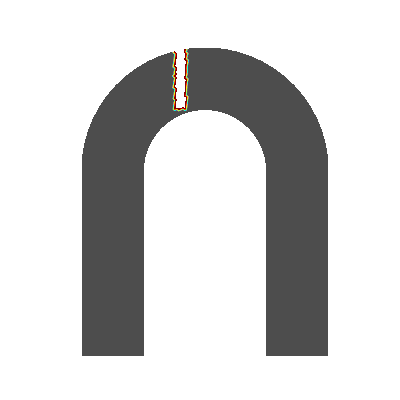

In [5]:
# First simulation in the dataset
fe.animate(u[0], Vh, cmap = gray_jet)

In [6]:
from dlroms.minns import Integral
u = dv.tensor(u).cpu()
ns, nt, nh = u.shape

space_integral = Integral(Vh)
clc()

def J(u):
  return space_integral(u).reshape(-1, nt).mean(axis = -1)

J(u).shape # Values of the functional J (see task (iii) - (iv)) across the dataset

J(u[:3]) # Values of the functional J on the first, second and third simulation

tensor([1.5723, 1.2846, 0.3781])

In [7]:
mu.shape,u.shape

((100, 3), torch.Size([100, 41, 6636]))

In [8]:
mu,u=dv.tensor(dataset['mu']),dv.tensor(dataset['u'])
display(mu.shape,u.shape)
ndata,ntimes,nh=u.shape
p=mu.shape[-1]
print("Trajectories:\t%d."% ndata)
print("Timesteps:\t%d."%ntimes)
print("FOM dimension:\t%d."%nh)
print("Parameters:\t%d."%p)

mut=dv.zeros(ndata,ntimes,p+1) #p+1 perche abbiamo la parametrizzazione + il tempo
times=dv.tensor(np.linspace(0,1,ntimes))
for i in range(ndata):
  mut[i,:,:3]=mu[i]
  mut[i,:,-1]=times

print(mut.shape) #tensore che contiene ndata x ntimes x (p+1)

torch.Size([100, 3])

torch.Size([100, 41, 6636])

Trajectories:	100.
Timesteps:	41.
FOM dimension:	6636.
Parameters:	3.
torch.Size([100, 41, 4])


In [9]:
u=u.reshape(-1,nh)
mut=mut.reshape(-1,p+1)
print(u.shape,mut.shape)

torch.Size([4100, 6636]) torch.Size([4100, 4])


In [10]:
l2=L2(Vh)
l2.cuda()
clc()
ntrain=75*ntimes #75 simulazioni per il train-set
ntest=25*ntimes  #25 simulazioni per il test-set
def error(utrue,upred):
  return ((l2(utrue-upred).reshape(-1,ntimes).sum(axis=-1))/l2(utrue).reshape(-1,ntimes).sum(axis=-1)).mean()

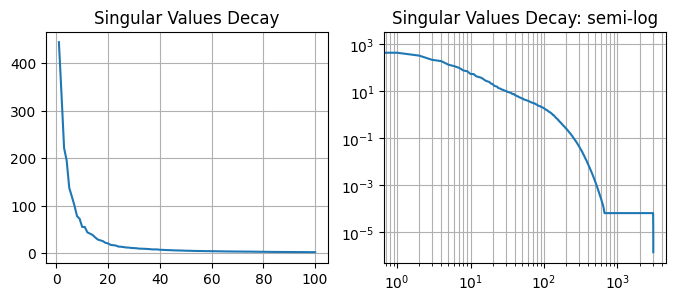

In [11]:
from scipy.linalg import svd
import matplotlib.pyplot as plt
%matplotlib inline

X,s,_=svd(u[:ntrain].T.cpu().numpy(),full_matrices=False)
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(1+np.arange(100),s[1:101])
plt.grid()
plt.title("Singular Values Decay")
plt.subplot(1,2,2)
plt.title("Singular Values Decay: semi-log")
plt.loglog(s)
plt.grid(True,which='both')
plt.show()

In [12]:
from torch.optim import Adam
rho_e=lambda x:relu(x) -10*relu(-x)
rho_d= lambda x:relu(x) -0.1*relu(-x)

Latent=9
encoder=Dense(nh,50,rho_e)+Dense(50,Latent,rho_e)
decoder=Dense(Latent,50,rho_d)+Dense(50,100,rho_d)+Dense(100,nh,activation=None)
autoencoder=DFNN(encoder+decoder)

autoencoder.He()
autoencoder.cuda()

autoencoder.train(u,u,ntrain=ntrain,  epochs=30, loss=mse(l2),
                  error=error,notation='%')

autoencoder.train(u,u,ntrain=ntrain, epochs=2000, loss=mse(l2),
                  optim=Adam, lr=1e-5, batchsize=64,
                  error=error, notation='%')




		Train	Test
Epoch 2000:	4.40%	4.91%.

>> ETA: 0.25s.

Training complete. Elapsed time: 8 minutes 21.23 seconds.


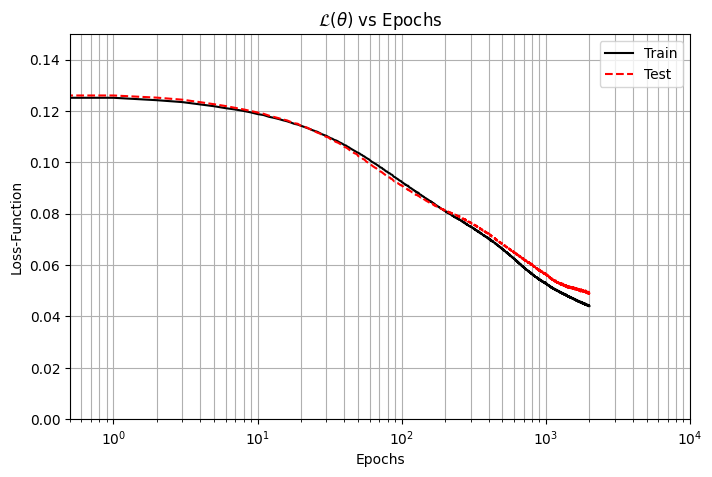

In [13]:

plt.figure(figsize = (8, 5))
plt.title(r'$\mathcal{L}(\theta)$ vs Epochs')
plt.semilogx(autoencoder.errors['Train'], '-k', label = 'Train')
#plt.semilogx(autoencoder.errors['Validation'], 'b', label = 'Validation')
plt.semilogx(autoencoder.errors['Test'], '--r', label = 'Test')
plt.xlabel('Epochs')
plt.ylabel('Loss-Function')
plt.axis([0.5, 1e+4, 0, 0.15])
plt.grid(True,which="both", ls="-")
plt.legend()
plt.show()

In [14]:
autoencoder.freeze()

In [15]:
print("Autoencoder MRE: %s"%num2p(error(u[ntrain:],autoencoder(u[ntrain:]))))

Autoencoder MRE: 4.91%


In [16]:
nu=encoder(u)
from dlroms.dnns import Fourier
fmodes=10
phi=DFNN(Fourier(fmodes, which=[-1]) + Dense(p+1+2*fmodes, 500, gelu) + Dense(500, Latent, activation = None))

phi.He()
phi.cuda()
phi.train(mut,nu,ntrain=ntrain, epochs=150,loss=mse(euclidean))
phi.freeze()

		Train		Test
Epoch 150:	7.92e+01	1.83e+03.

>> ETA: 0.65s.

Training complete. Elapsed time: 1 minutes 36.87 seconds.


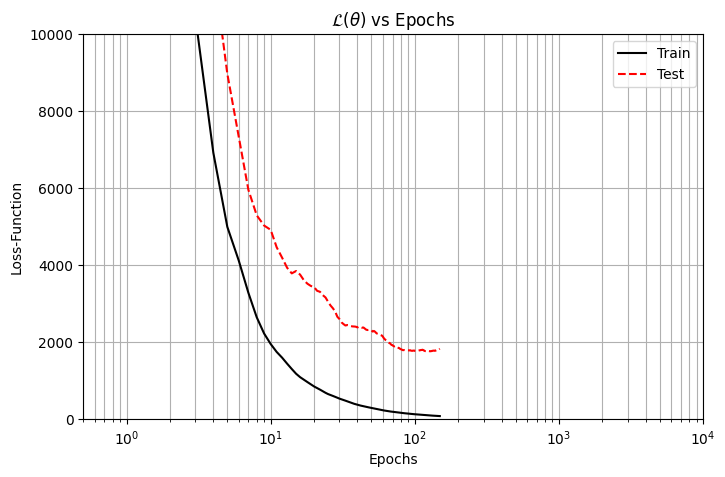

In [17]:
plt.figure(figsize = (8, 5))
plt.title(r'$\mathcal{L}(\theta)$ vs Epochs')
plt.semilogx(phi.errors['Train'], '-k', label = 'Train')
plt.semilogx(phi.errors['Test'], '--r', label = 'Test')
plt.xlabel('Epochs')
plt.ylabel('Loss-Function')
plt.axis([0.5, 1e+4, 0, 1e+4])
plt.grid(True,which="both", ls="-")
plt.legend()
plt.show()

In [18]:
dlrom = lambda mt: decoder(phi(mt))
num2p(error(u[ntrain:], dlrom(mut[ntrain:])))

'9.19%'

In [19]:
def visualize(uexample):
    fe.animate(uexample[::2], Vh, figsize = (8, 2),colorbar=True)

#visualize(u[0])

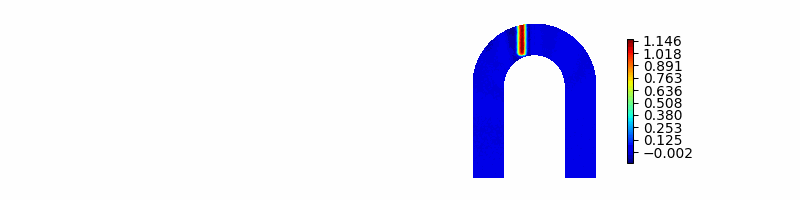

DL-ROM simulation time: 0.003s.


In [20]:
from time import perf_counter
mu0 = dv.tensor([5.8e-01, 7.2e-01, 6.1e-01])

mu0t = dv.zeros(ntimes, p+1)
mu0t[:, 3] = times
mu0t[:, :3] = mu0

t0 = perf_counter()
uROM = dlrom(mu0t)
t1 = perf_counter()
visualize(uROM)
print("DL-ROM simulation time: %.3fs." % (t1-t0))

In [21]:
print(uROM.shape)
uROM_III=uROM.cpu()
print(uROM_III.shape)
J(uROM_III)  #la funzione "J" prende dentro un torch.tensor() non np.array() !

torch.Size([41, 6636])
torch.Size([41, 6636])


tensor([1.6446])

In [22]:
print(mu[:,0].shape)
print(mut.reshape(100,41,-1).shape)
mut=mut.reshape(100,41,-1)

torch.Size([100])
torch.Size([100, 41, 4])


In [23]:
uROM_out=[]                       #list
mut_eval=dv.zeros(ndata,ntimes,4) #tensor
for i in range(ndata):            #ndata=100
    mut_eval=mut[i,:,:]           #variation of parameters per single simulation
    uROM=dlrom(mut_eval)          #evalutation of mut-tensor by means of the surrogate model! (performing 100 simulations in 0.4s)
    uROM_out.append(uROM.cpu().numpy())

uROM_val=np.stack(uROM_out)
print(uROM_val.shape)

(100, 41, 6636)


In [24]:
import torch
uROM_val=torch.from_numpy(uROM_val)
J(uROM_val)

tensor([1.5719, 1.2890, 0.3766, 1.5233, 1.5759, 1.6332, 0.8792, 1.1420, 4.5279,
        0.6125, 0.4238, 0.3308, 1.1047, 0.6612, 1.7623, 0.5027, 0.7630, 0.7878,
        1.0692, 1.0974, 2.7203, 0.4610, 0.6861, 2.9363, 2.2823, 1.5145, 0.8100,
        1.7859, 1.2180, 0.6670, 0.8119, 2.3625, 0.9389, 0.6697, 1.0604, 0.5768,
        1.4256, 1.1754, 1.9445, 1.9472, 0.3979, 0.3648, 2.5473, 0.7723, 0.5109,
        1.5574, 1.5832, 2.0631, 1.4149, 0.5010, 0.5073, 0.4142, 0.3964, 1.4415,
        0.6189, 1.9936, 0.9399, 0.4116, 0.7486, 0.6051, 0.4364, 0.6064, 0.6164,
        0.6894, 0.9549, 0.3284, 0.3697, 2.3053, 0.3583, 1.5299, 3.5467, 0.5782,
        0.9546, 1.1445, 1.3140, 0.4426, 1.5919, 1.9102, 0.9020, 0.8704, 1.4421,
        0.6008, 1.0113, 1.0918, 0.4771, 1.0297, 0.4025, 3.3828, 1.0727, 0.5371,
        0.3886, 0.5174, 2.6273, 1.4271, 1.4363, 0.4411, 1.8645, 4.3654, 1.2931,
        1.0500])

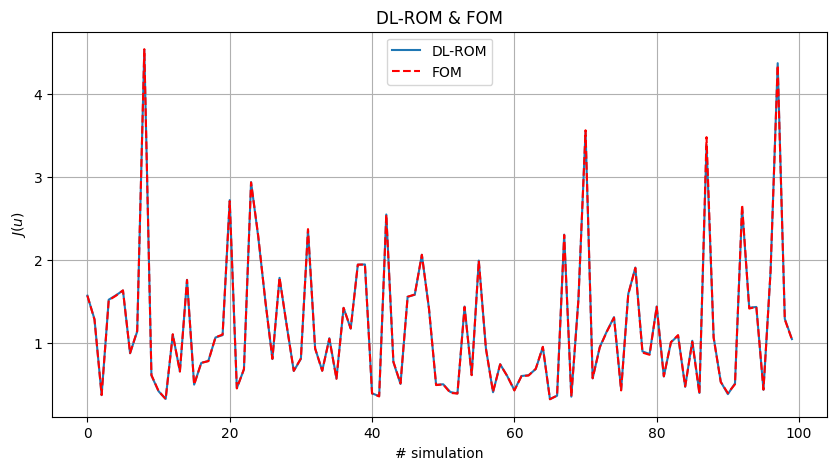

In [25]:
%matplotlib inline
plt.figure(figsize=(10,5))
plt.title("DL-ROM & FOM")
plt.plot(J(uROM_val),label="DL-ROM")
plt.plot(J(u.cpu()),color='r',ls='dashed',label="FOM")
plt.legend()
plt.ylabel(r'$J(u)$')
plt.xlabel('# simulation')
plt.grid()
plt.show()

Difference between the DL-ROM and the FOM in order to check the goodness of the approximation acchieved

In [26]:
diff=J(uROM_val)-J(u.cpu()) #difference

Text(0, 0.5, '$J(\\tilde{u})-J(u)$')

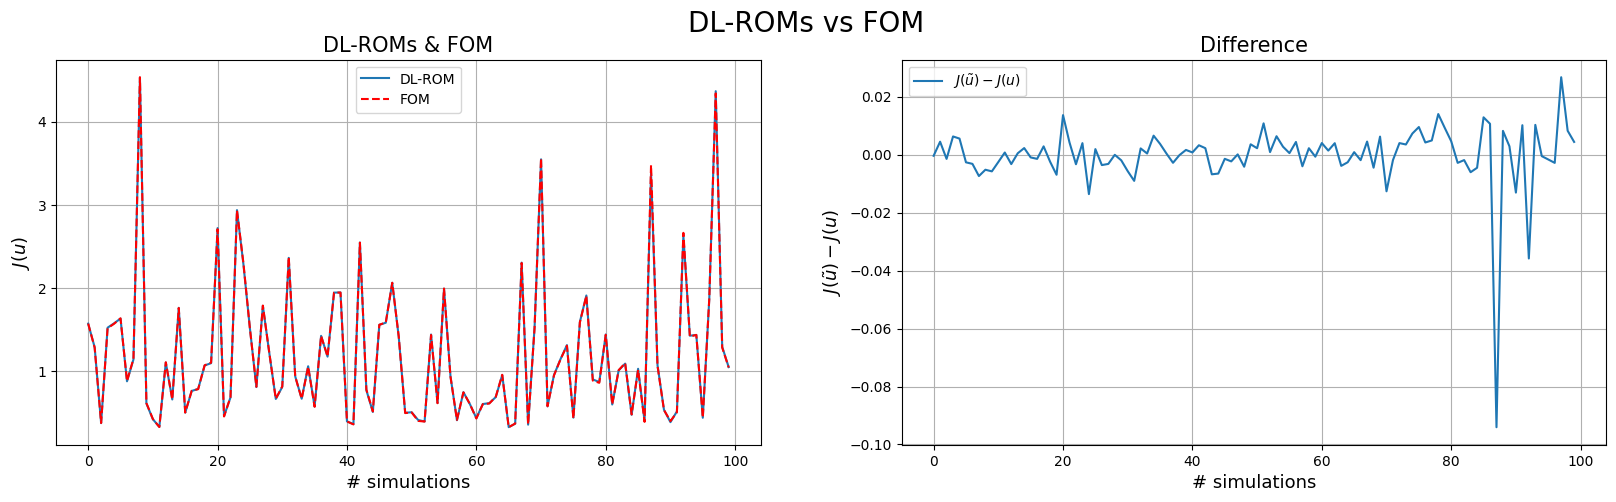

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(20,5))
fig.suptitle('DL-ROMs vs FOM',size="20")
ax1.set_title("DL-ROMs & FOM",size="15")
ax1.plot(J(uROM_val),label="DL-ROM")
ax1.plot(J(u.cpu()),color='r',ls='dashed',label="FOM")
ax1.grid()
ax1.set_xlabel("# simulations",size="13")
ax1.set_ylabel("$J(u)$",size="13")
ax1.legend()
ax2.set_title("Difference",size="15")
ax2.plot(diff,label=r"$J(\tilde{u})-J(u)$")
ax2.grid()
ax2.legend()
ax2.set_xlabel("# simulations",size="13")
ax2.set_ylabel(r"$J(\tilde{u})-J(u)$",size="13")

# Point: IV

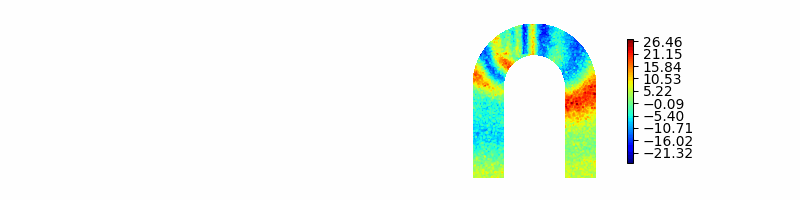

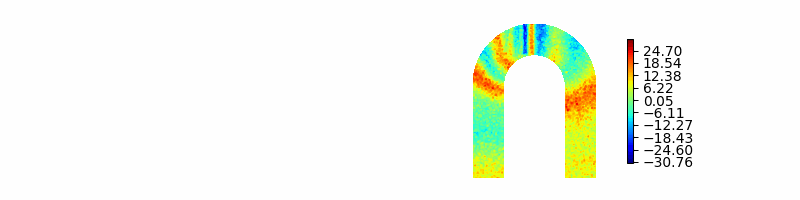

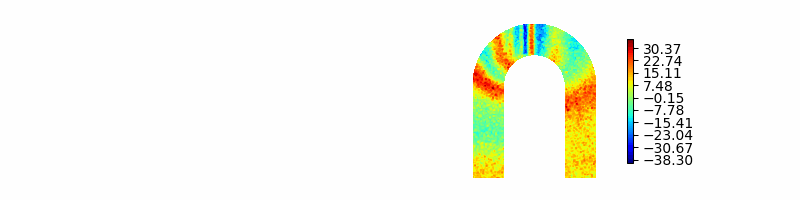

(3, 41, 6636)
torch.Size([3])
tensor([ 8.4539, 25.5776, 40.6931])


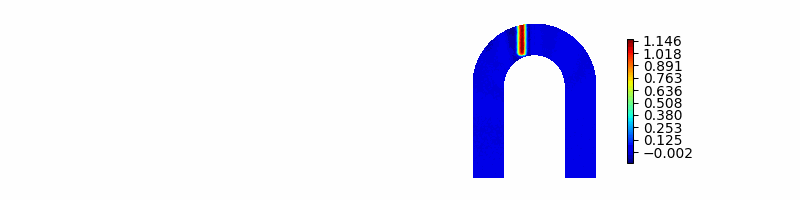

DL-ROM simulation time: 0.001s.


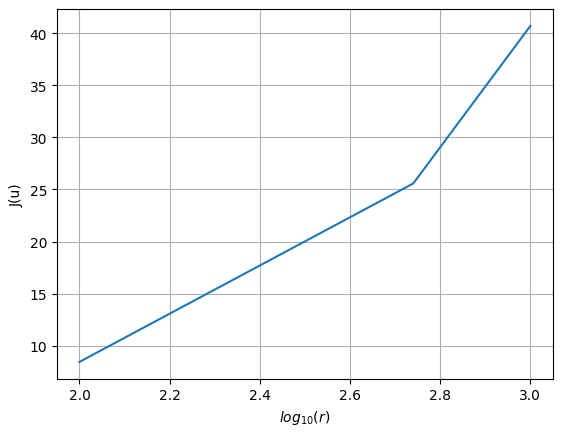

In [28]:
delta_values=np.linspace(1,2,3) #1, 1.5, 2
uROM_4l=[]
for i,delta in enumerate(delta_values):    #iterable
    mu0 = dv.tensor([np.sqrt(10), delta, 6.1e-01])
    mu0t = dv.zeros(ntimes, p+1)
    mu0t[:, 3] = times
    mu0t[:, :3] = mu0
    uROM_4 = dlrom(mu0t)
    visualize(uROM_4)
    uROM_4l.append(uROM_4.cpu().numpy())

uROM_4=np.stack(uROM_4l)
print(uROM_4.shape)

#J(u) evaluation and plotting
uROM_4=torch.from_numpy(uROM_4)
J_4=J(uROM_4)
print(J_4.shape)
print(J_4)
r=np.linspace(100,1000,3)
logr=np.log10(r)
plt.plot(logr,J_4)
plt.xlabel(r'$log_{10}(r)$')
plt.ylabel(r'J(u)')
plt.grid()


#Based (trusted) parameters
mu0 = dv.tensor([5.8e-01, 7.2e-01, 6.1e-01])

mu0t = dv.zeros(ntimes, p+1)
mu0t[:, 3] = times
mu0t[:, :3] = mu0

t0 = perf_counter()
uROM = dlrom(mu0t)
t1 = perf_counter()
visualize(uROM)
print("DL-ROM simulation time: %.3fs." % (t1-t0))

Ciò che si nota selezionando come set di parametri $\boldsymbol{\mu} =[\sqrt{10}, \delta , 0.61]^T$ con $\delta\in \{1,1.5,2\}$ è che spostarsi troppo dai valori di $\boldsymbol{\mu}=[0.58, 0.72, 0.61]^T$ produce una simulazione che non viene ben approssimata dal modello surrogato, chiedere $D=\sqrt{10}$ significa aumentare di $6$ volte il valore di $0.58$ il che è eccessivo. Facendo dei test il modello approssimato con DL-ROM sembra tollerare all'incirca un valore doppio dei parametri, probabilmente per andare oltre bisogna includere meglio la dinamica del problema, come? Usando Autoencoder+SINDy

# SINDy (problemi)

non viene considerato il tempo nella dinamica di sindy

In [29]:
from SINDy_Rares import *

In [30]:
z=encoder(u)
print(z.shape)

torch.Size([4100, 9])


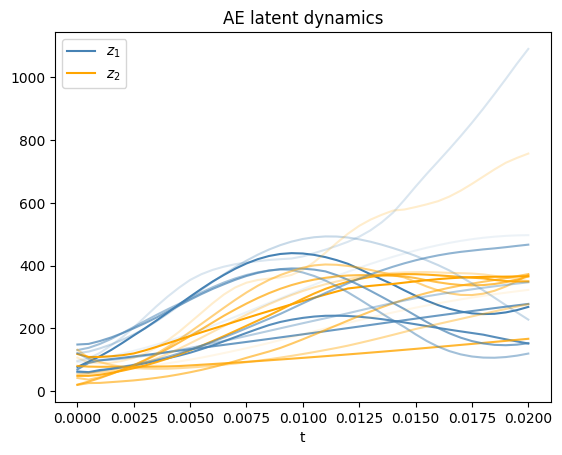

In [31]:


t = np.arange(ntimes)*5e-4

for i in range(10):
  plot(t, z.reshape(-1, ntimes, latent)[i][:, 0], color = 'steelblue', alpha = 1.0 - i/10, label = '$z_1$' if i==0 else None)
  plot(t, z.reshape(-1, ntimes, latent)[i][:, 1], color = 'orange', alpha = 1.0 - i/10, label = '$z_2$' if i==0 else None)

plt.legend()
plt.xlabel("t")
plt.title("AE latent dynamics")
None

In [32]:
from dlroms.dnns import Reshape
Xi = Library([lambda x: x, lambda x: x**2, (lambda x: x[:,0:1]*x[:,1:2]) if latent > 1 else (lambda x: 0*x[:,0:1]), lambda x: x**3, lambda x: 1.0 + 0*x])

latent=9
m = Xi(dv.zeros(1, latent)).shape[-1]
p = mu.shape[-1]


eta = Dense(p, 50, gelu) + Dense(50, 50, gelu) + Dense(50,m*latent, None) + Reshape(latent, m)
sindy = SINDy(eta, Xi = Xi)
sindy.He()
sindy.cuda()

In [33]:
mu_repeated = (dv.zeros(ndata, ntimes, 1) + mu.reshape(ndata, 1, -1)).reshape(ndata*ntimes, -1)
sindy.train((mu_repeated, z), z, loss = sindy_loss, error = sindy_error, epochs = 50, ntrain = ntrain)
sindy.train((mu_repeated, z), z, loss = sindy_loss, error = sindy_error, epochs = 500, ntrain = ntrain, optim = Adam, lr = 1e-3, batchsize = ntimes)

		Train		Test
Epoch 500:	5.07e+09	5.67e+09.

>> ETA: 0.24s.

Training complete. Elapsed time: 1 minutes 58.05 seconds.


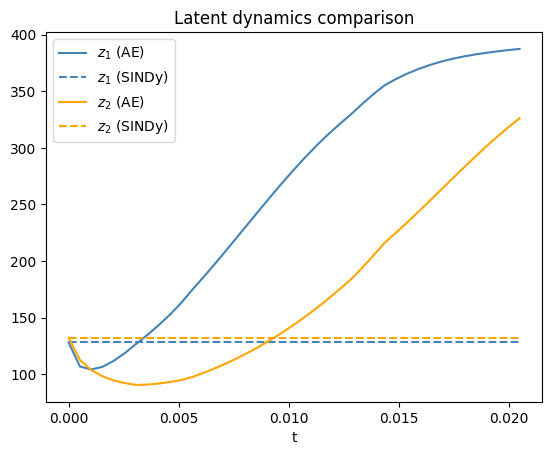

In [34]:
sindy.freeze()

ztrue = encoder(u).reshape(-1, ntimes, latent)
z0s = ztrue[:, 0]
zsindy = sindy.evolve(mu_repeated.reshape(ndata, ntimes, -1)[:, 0], z0s, steps = ntimes-1, tau = 5e-4)
t_sindy= np.linspace(0, 0.0205, 41)
which = -1
plot(t_sindy, ztrue[which, :, 0], color = 'steelblue', label = '$z_1$ (AE)')
plot(t_sindy, zsindy[which, :, 0], '--', color = 'steelblue', label = '$z_1$ (SINDy)')
plot(t_sindy, ztrue[which, :, 1], color = 'orange', label = '$z_2$ (AE)')
plot(t_sindy, zsindy[which, :, 1], '--', color = 'orange', label = '$z_2$ (SINDy)')
plt.legend()
plt.xlabel("t")
plt.title("Latent dynamics comparison")
None

## PySINDy
Utilizzare SINDy in questo caso può essere interessante per fittare la soluzione e ri-trovare la "governing equation" del problema U-bolt

In [35]:
import pysindy as ps

t = np.linspace(0, 0.0205, 41)
print(t.shape)
coords = mesh.coordinates()[:,:2] #coordinates from fenics-mesh
print(np.shape(coords))

(41,)
(6636, 2)


In [36]:
u=u.reshape(ndata,len(t),-1)
print(u.shape)
u=u.cpu().numpy()

torch.Size([100, 41, 6636])


In [37]:
dt=5e-4
u_sol = u[0, :, :] #0 is the number of simulation 100 is the last one, "ndata"
print(u_sol.shape)
u_dot = ps.SmoothedFiniteDifference(axis=0,order=1,d=1)._differentiate(u_sol, dt) # "SmoothedFiniteDifference" for noisy data (1. Filtered -> 2. Central Euler Scheme)

# best practice 75 % of data for training 
train = np.random.choice(ntimes, int(ntimes * 1), replace=False)
test = [i for i in np.arange(len(times)) if i not in train]
u_train = u[0, train,: ]
u_test = u[0, test, :]
u_dot_train = u_dot[ train,: ]
u_dot_test = u_dot[ test, :]
t_train = t[train]
t_test = t[test]

(41, 6636)


In [38]:
print(np.shape(u_train))
print(np.shape(u_test))
print(np.shape(u_dot_train))
print(np.shape(coords))

(41, 6636)
(0, 6636)
(41, 6636)
(6636, 2)


# Model discovery on the FOM data
Devo ora in qualche modo introdurre derivate del secondo ordine nel modello in quanto cio che viene recuperato da SINDy è solo un problema di trasporto, quando so per certo che il problema è di "diffusione + reazione" quindi ci sono derivate seconde: Laplaciano + Reazione non lineare. Cio  che trova SINDy è un problema di "mild-transport" non lineare a sua volta con ulteriori 3 termini di reazione di cui 2 non lineari. La determinazione della PDE finale dipende estremamente dalla selezione della _threshold_ in $\texttt{STLSQ}$ e dal valore di penalty (sparsity constrain) $\lambda$

$$\partial_t u = 526.401 u -534.151 u^2 -0.007 \nabla_x u + 0.018 u\cdot\nabla_x u + -0.009 u^2\cdot\nabla_x u$$


In [39]:
x=np.linspace(0,1,nh)             # x for SINDy

In [40]:
u2fit=u[0,:,:]
u2fit=u2fit.reshape(6636,41,1)
u_dot_2fit=u_dot.reshape(6636,41,1)
print(u2fit.shape,u_dot_2fit.shape)

train = np.random.choice(ntimes, int(ntimes * 0.75), replace=False)
test = [i for i in np.arange(len(times)) if i not in train]


(6636, 41, 1) (6636, 41, 1)


In [41]:

pde_lib = ps.PDELibrary(
    function_library=ps.PolynomialLibrary(degree=2,include_bias=False),
    derivative_order=2,  # up to second-order spatial derivaties
    spatial_grid=x,
    include_bias=False,  # cross terms u * u_x, etc.
    is_uniform=False,    # for unstructured grid
    periodic=True
)
stlsq_optimizer = ps.STLSQ(threshold=1, alpha=1e-5,max_iter=200, verbose=True,normalize_columns=True)

optimizer = ps.SR3(
    reg_weight_lam=0.005,
        regularizer="L0",
        relax_coeff_nu=1.0e+2,
        tol=1e-5,
        trimming_fraction=0.0,
        trimming_step_size=1.0,
        max_iter=1000,
        copy_X=True,
        initial_guess=None,
        normalize_columns=True,
        verbose=True,
        unbias=True,
)

n_train=35 # train_data for the time

model = ps.SINDy(feature_library=pde_lib, optimizer=stlsq_optimizer)
model.fit(u2fit[:,:n_train,:], x_dot=u_dot_2fit[:,:n_train,:],t=dt) # Fitting method from sklearn
model.print()
gamma=model.predict(u2fit[:,n_train:,:])
"""gamma=np.squeeze(gamma)
print(gamma.shape)
plt.pcolormesh(t[30:], x, gamma)
plt.colorbar( label="u(x,t)")
plt.xlabel(r't')
plt.ylabel(r'x')
plt.show()"""

/home/orion/anaconda3/envs/dl-rom/lib/python3.10/site-packages/pysindy/feature_library/pde_library.py:110: UserWarning: is_uniform and periodic have been deprecated.in favor of differetiation_method and diff_kwargs.
  warnings.warn(


 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 5.7902e+07 ... 1.7205e+05 ...          8 ... 5.8074e+07
(x0)' = 527.393 x0 + -537.536 x0^2 + -0.007 x0_1 + 0.019 x0x0_1 + -0.010 x0^2x0_1


'gamma=np.squeeze(gamma)\nprint(gamma.shape)\nplt.pcolormesh(t[30:], x, gamma)\nplt.colorbar( label="u(x,t)")\nplt.xlabel(r\'t\')\nplt.ylabel(r\'x\')\nplt.show()'

# Fitting Error
Non ha senso ne il total error in ```verbose``` e neppure calcolare:
$$E=\frac{1}{N_{test}}\sum_{i=1}^{N_{test}}\frac{|y-y_{pred}|}{|u_{test}|}$$ 
in quanto $y$ sono i dati gia integrati cioè $u$, mentre cio che produce ```model.predict()``` sono dati in funzione di $\partial_t u$ quindi una funzione da integrare.

pertanto per calcolare l'errore ho bisogno di $\dot{u}_{test}$ a cui gli sottraggo il mio $\partial_t u$:
$$E=\frac{1}{N_{test}}\sum_{i=1}^{N_{test}}\frac{|\dot{u}_{test}-\partial_t u|}{|\dot{u}_{test}|}$$ 

In [42]:
print(np.squeeze(u2fit[:,n_train:,:]).shape)


# X_test: library( state, grads,... ),  shape (n_test, k)
# xdot_test: numerical time-derivative on the same points, shape (n_test, d)
      # or model.predict(x_test) if using PySINDy’s internal library
Utest=np.squeeze(u_dot_2fit[:,n_train:,:])
print(Utest.shape)
Utest_pred=np.array(gamma).squeeze()
print(Utest_pred.shape)

        
error=np.mean(np.linalg.norm(Utest-Utest_pred,axis=0)/ np.linalg.norm(Utest,axis=0))
num2p(error)


(6636, 6)
(6636, 6)
(6636, 6)


'35.95%'

### Parametric scan for Threshold-Value

In [50]:
threshold_scan=np.linspace(500,2e+3,10)

coefs=[]
for i,threshold in enumerate(threshold_scan):
    opt=ps.STLSQ(threshold=threshold, alpha=1e-16,max_iter=200, verbose=True,normalize_columns=True)
    model=ps.SINDy(feature_library=pde_lib,optimizer=opt)
    print(f'num= {i}, threshold value= {threshold}')
    model.fit(u2fit[:,:n_train,:], x_dot=u_dot_2fit[:,:n_train,:],t=dt)
    model.print()
    coefs.append(model.coefficients())

num= 0, threshold value= 500.0
 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 5.7902e+07 ... 1.7225e-06 ...          8 ... 5.7902e+07
(x0)' = 527.393 x0 + -537.536 x0^2 + -0.007 x0_1 + 0.019 x0x0_1 + -0.010 x0^2x0_1
num= 1, threshold value= 666.6666666666666
 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 5.7902e+07 ... 1.7225e-06 ...          8 ... 5.7902e+07
(x0)' = 527.393 x0 + -537.536 x0^2 + -0.007 x0_1 + 0.019 x0x0_1 + -0.010 x0^2x0_1
num= 2, threshold value= 833.3333333333333
 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 5.8567e+07 ... 1.7224e-06 ...          7 ... 5.8567e+07
         1 ... 5.7926e+07 ... 1.7211e-06 ...          7 ... 5.7926e+07
(x0)' = 527.271 x0 + -537.411 x0^2 + -0.006 x0_1 + 0.010 x0x0_1
num= 3, threshold value= 1000.0
 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |

### Usando SR3

In [44]:
"""print('SR3 model, L0 norm: ')
optimizer = ps.SR3(
    reg_weight_lam=0.005,
        regularizer="L0",
        relax_coeff_nu=1.0e+2,
        tol=1e-5,
        trimming_fraction=0.0,
        trimming_step_size=1.0,
        max_iter=1000,
        copy_X=True,
        initial_guess=None,
        normalize_columns=True,
        verbose=True,
        unbias=False,
)
model = ps.SINDy(feature_library=pde_lib, optimizer=optimizer)
model.fit(u_flat, x_dot=u_dot_flat)
model.print()"""

'print(\'SR3 model, L0 norm: \')\noptimizer = ps.SR3(\n    reg_weight_lam=0.005,\n        regularizer="L0",\n        relax_coeff_nu=1.0e+2,\n        tol=1e-5,\n        trimming_fraction=0.0,\n        trimming_step_size=1.0,\n        max_iter=1000,\n        copy_X=True,\n        initial_guess=None,\n        normalize_columns=True,\n        verbose=True,\n        unbias=False,\n)\nmodel = ps.SINDy(feature_library=pde_lib, optimizer=optimizer)\nmodel.fit(u_flat, x_dot=u_dot_flat)\nmodel.print()'

In [45]:
print("2nd order derivative library: ")
print(pde_lib.get_feature_names())

2nd order derivative library: 
['x0', 'x0^2', 'x0_1', 'x0_11', 'x0x0_1', 'x0^2x0_1', 'x0x0_11', 'x0^2x0_11']
